# Understanding Convolution Tensor Operations Step by Step

This notebook teaches convolution operations from the ground up, starting with the fundamental mathematical concept and progressing to deep learning applications.

**How to use this notebook:**
1. Read each explanation carefully
2. Try to predict what the output will be
3. Run the cell to verify your understanding
4. Experiment with different parameters to build intuition

**Learning Path:**
- 1D Convolution (signal processing)
- 2D Convolution (image processing)
- Convolution in Neural Networks
- Padding, Stride, and Dilation
- Transposed Convolution


## Setup

Let's import the necessary libraries for this tutorial.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.9.0+cu128
CUDA available: True


## Part 1: What is Convolution?

**Convolution** is a mathematical operation that combines two functions to produce a third function. In the context of tensors and deep learning:

- **Input signal**: The data we want to process (image, audio, etc.)
- **Kernel/Filter**: A small matrix that slides over the input
- **Output**: A feature map showing where the kernel matches patterns in the input

The key idea: **The kernel slides over the input, and at each position, we compute the element-wise product and sum the results.**

Let's start with the simplest case: 1D convolution.


## Part 2: 1D Convolution (Manual Example)

Let's manually compute a 1D convolution to understand exactly what happens.

**Example:**
- Input: `[1, 2, 3, 4, 5]`
- Kernel: `[1, -1]`
- Output: ?

**Step-by-step process:**
1. Place kernel at position 0: kernel `[1, -1]` aligns with input `[1, 2]`
2. Multiply element-wise: `1*1 + 2*(-1) = 1 - 2 = -1`
3. Slide kernel one position: kernel `[1, -1]` aligns with input `[2, 3]`
4. Multiply: `2*1 + 3*(-1) = 2 - 3 = -1`
5. Continue...


In [2]:
# Manual 1D convolution example
input_1d = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
kernel_1d = torch.tensor([1.0, -1.0])

print("Input:", input_1d)
print("Kernel:", kernel_1d)
print("\nManual computation:")

# Compute convolution manually
output = []
for i in range(len(input_1d) - len(kernel_1d) + 1):
    window = input_1d[i:i+len(kernel_1d)]
    result = (window * kernel_1d).sum()
    output.append(result)
    print(f"Position {i}: window={window.tolist()}, result={result:.1f}")

output_tensor = torch.tensor(output)
print(f"\nOutput: {output_tensor}")


Input: tensor([1., 2., 3., 4., 5.])
Kernel: tensor([ 1., -1.])

Manual computation:
Position 0: window=[1.0, 2.0], result=-1.0
Position 1: window=[2.0, 3.0], result=-1.0
Position 2: window=[3.0, 4.0], result=-1.0
Position 3: window=[4.0, 5.0], result=-1.0

Output: tensor([-1., -1., -1., -1.])


### 1D Convolution with PyTorch

PyTorch provides `conv1d` for 1D convolutions. However, note that:
- PyTorch expects inputs in shape: `(batch, channels, length)`
- Kernels are in shape: `(out_channels, in_channels, kernel_size)`

Let's see how it works:


In [3]:
# PyTorch 1D convolution
# Input shape: (batch=1, channels=1, length=5)
input_pt = input_1d.unsqueeze(0).unsqueeze(0)  # Shape: [1, 1, 5]
kernel_pt = kernel_1d.unsqueeze(0).unsqueeze(0)  # Shape: [1, 1, 2]

print("Input shape:", input_pt.shape)
print("Kernel shape:", kernel_pt.shape)

# Create conv1d layer
conv1d = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=2, bias=False)
# Set the kernel weights manually
conv1d.weight.data = kernel_pt

# Apply convolution
output_pt = conv1d(input_pt)
print("\nPyTorch output shape:", output_pt.shape)
print("PyTorch output:", output_pt.squeeze())
print("\nMatches manual computation?", torch.allclose(output_pt.squeeze(), output_tensor))


Input shape: torch.Size([1, 1, 5])
Kernel shape: torch.Size([1, 1, 2])

PyTorch output shape: torch.Size([1, 1, 4])
PyTorch output: tensor([-1., -1., -1., -1.], grad_fn=<SqueezeBackward0>)

Matches manual computation? True


## Part 3: 2D Convolution (The Most Common Case)

2D convolution is what's used in image processing and CNNs. The kernel is a 2D matrix that slides over a 2D input.

**Visual analogy:** Imagine you have a small window (kernel) that you slide over a large image. At each position, you multiply the overlapping pixels and sum them up.

Let's work through a concrete example.


In [4]:
# Create a simple 2D input (e.g., a small image)
input_2d = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [9.0, 10.0, 11.0, 12.0],
    [13.0, 14.0, 15.0, 16.0]
])

# Create a simple 2x2 kernel (e.g., edge detector)
kernel_2d = torch.tensor([
    [1.0, 0.0],
    [0.0, -1.0]
])

print("Input (4x4):")
print(input_2d)
print("\nKernel (2x2):")
print(kernel_2d)


Input (4x4):
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

Kernel (2x2):
tensor([[ 1.,  0.],
        [ 0., -1.]])


### Manual 2D Convolution Computation

Let's compute the first few outputs manually to see exactly what happens:

**Position (0,0):**
- Window: `[[1, 2], [5, 6]]`
- Kernel: `[[1, 0], [0, -1]]`
- Result: `1*1 + 2*0 + 5*0 + 6*(-1) = 1 - 6 = -5`

**Position (0,1):**
- Window: `[[2, 3], [6, 7]]`
- Result: `2*1 + 3*0 + 6*0 + 7*(-1) = 2 - 7 = -5`

Let's verify:


In [5]:
# Manual 2D convolution
kernel_h, kernel_w = kernel_2d.shape
input_h, input_w = input_2d.shape
output_h = input_h - kernel_h + 1
output_w = input_w - kernel_w + 1

output_2d = torch.zeros(output_h, output_w)

print("Computing 2D convolution manually:\n")
for i in range(output_h):
    for j in range(output_w):
        window = input_2d[i:i+kernel_h, j:j+kernel_w]
        result = (window * kernel_2d).sum()
        output_2d[i, j] = result
        print(f"Position ({i},{j}): window=\n{window}\nresult={result:.1f}\n")

print("Final output:")
print(output_2d)


Computing 2D convolution manually:

Position (0,0): window=
tensor([[1., 2.],
        [5., 6.]])
result=-5.0

Position (0,1): window=
tensor([[2., 3.],
        [6., 7.]])
result=-5.0

Position (0,2): window=
tensor([[3., 4.],
        [7., 8.]])
result=-5.0

Position (1,0): window=
tensor([[ 5.,  6.],
        [ 9., 10.]])
result=-5.0

Position (1,1): window=
tensor([[ 6.,  7.],
        [10., 11.]])
result=-5.0

Position (1,2): window=
tensor([[ 7.,  8.],
        [11., 12.]])
result=-5.0

Position (2,0): window=
tensor([[ 9., 10.],
        [13., 14.]])
result=-5.0

Position (2,1): window=
tensor([[10., 11.],
        [14., 15.]])
result=-5.0

Position (2,2): window=
tensor([[11., 12.],
        [15., 16.]])
result=-5.0

Final output:
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]])


### 2D Convolution with PyTorch

Now let's use PyTorch's `conv2d` to do the same computation. The input shape is `(batch, channels, height, width)`.


In [6]:
# PyTorch 2D convolution
# Input shape: (batch=1, channels=1, height=4, width=4)
input_pt_2d = input_2d.unsqueeze(0).unsqueeze(0)  # Shape: [1, 1, 4, 4]
kernel_pt_2d = kernel_2d.unsqueeze(0).unsqueeze(0)  # Shape: [1, 1, 2, 2]

print("Input shape:", input_pt_2d.shape)
print("Kernel shape:", kernel_pt_2d.shape)

# Create conv2d layer
conv2d = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, bias=False)
conv2d.weight.data = kernel_pt_2d

# Apply convolution
output_pt_2d = conv2d(input_pt_2d)
print("\nPyTorch output shape:", output_pt_2d.shape)
print("PyTorch output:")
print(output_pt_2d.squeeze())
print("\nMatches manual computation?", torch.allclose(output_pt_2d.squeeze(), output_2d))


Input shape: torch.Size([1, 1, 4, 4])
Kernel shape: torch.Size([1, 1, 2, 2])

PyTorch output shape: torch.Size([1, 1, 3, 3])
PyTorch output:
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]], grad_fn=<SqueezeBackward0>)

Matches manual computation? True


## Part 4: Understanding Output Size

The output size of a convolution depends on:
- Input size: `(H_in, W_in)`
- Kernel size: `(K_h, K_w)`
- Padding: `P` (we'll learn about this next)
- Stride: `S` (we'll learn about this next)

**Basic formula (no padding, stride=1):**
- Output height: `H_out = H_in - K_h + 1`
- Output width: `W_out = W_in - K_w + 1`

In our example: `4 - 2 + 1 = 3`

Let's verify this:


In [7]:
# Verify output size calculation
H_in, W_in = 4, 4
K_h, K_w = 2, 2
H_out = H_in - K_h + 1
W_out = W_in - K_w + 1

print(f"Input size: ({H_in}, {W_in})")
print(f"Kernel size: ({K_h}, {K_w})")
print(f"Output size: ({H_out}, {W_out})")
print(f"\nActual output shape: {output_pt_2d.squeeze().shape}")
assert output_pt_2d.squeeze().shape == (H_out, W_out), "Size mismatch!"
print("✓ Size calculation is correct!")


Input size: (4, 4)
Kernel size: (2, 2)
Output size: (3, 3)

Actual output shape: torch.Size([3, 3])
✓ Size calculation is correct!


## Part 5: Padding - Keeping the Output Size the Same

One problem with convolution: **the output is smaller than the input!**

**Padding** solves this by adding zeros (or other values) around the input before convolution.

- **Padding=1**: Adds 1 layer of zeros around the input
- With padding, output size = input size (if kernel is odd) or input size - 1 (if kernel is even)

**Visual example with padding=1:**
```
Original:     Padded (padding=1):
[1 2 3]   →   [0 0 0 0 0]
[4 5 6]       [0 1 2 3 0]
[7 8 9]       [0 4 5 6 0]
              [0 7 8 9 0]
              [0 0 0 0 0]
```


In [8]:
# Convolution with padding
input_padded = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0]
])

kernel_3x3 = torch.tensor([
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0]
])

print("Input (3x3):")
print(input_padded)
print("\nKernel (3x3):")
print(kernel_3x3)

# Without padding
conv_no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0, bias=False)
conv_no_pad.weight.data = kernel_3x3.unsqueeze(0).unsqueeze(0)
input_batch = input_padded.unsqueeze(0).unsqueeze(0)
output_no_pad = conv_no_pad(input_batch)

print(f"\nWithout padding - Output size: {output_no_pad.squeeze().shape}")
print(output_no_pad.squeeze())

# With padding=1
conv_with_pad = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_with_pad.weight.data = kernel_3x3.unsqueeze(0).unsqueeze(0)
output_with_pad = conv_with_pad(input_batch)

print(f"\nWith padding=1 - Output size: {output_with_pad.squeeze().shape}")
print(output_with_pad.squeeze())


Input (3x3):
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

Kernel (3x3):
tensor([[ 1.,  0., -1.],
        [ 1.,  0., -1.],
        [ 1.,  0., -1.]])

Without padding - Output size: torch.Size([])
tensor(-6., grad_fn=<SqueezeBackward0>)

With padding=1 - Output size: torch.Size([3, 3])
tensor([[ -7.,  -4.,   7.],
        [-15.,  -6.,  15.],
        [-13.,  -4.,  13.]], grad_fn=<SqueezeBackward0>)


### Output Size Formula with Padding

With padding `P` and stride `S=1`:
- `H_out = H_in + 2*P - K_h + 1`
- `W_out = W_in + 2*P - K_w + 1`

For "same" padding (output size = input size), we need:
- `P = (K - 1) / 2` (when K is odd)

Let's verify:


In [9]:
# Verify padding formula
H_in, W_in = 3, 3
K = 3
P = 1

H_out_padded = H_in + 2*P - K + 1
W_out_padded = W_in + 2*P - K + 1

print(f"Input size: ({H_in}, {W_in})")
print(f"Kernel size: {K}x{K}")
print(f"Padding: {P}")
print(f"Calculated output size: ({H_out_padded}, {W_out_padded})")
print(f"Actual output size: {output_with_pad.squeeze().shape}")
assert output_with_pad.squeeze().shape == (H_out_padded, W_out_padded), "Size mismatch!"
print("✓ Padding formula is correct!")


Input size: (3, 3)
Kernel size: 3x3
Padding: 1
Calculated output size: (3, 3)
Actual output size: torch.Size([3, 3])
✓ Padding formula is correct!


## Part 6: Stride - Skipping Positions

**Stride** controls how many positions the kernel moves at each step.

- **Stride=1**: Kernel moves one position at a time (normal)
- **Stride=2**: Kernel moves two positions at a time (output is half the size)
- **Stride=3**: Kernel moves three positions at a time (output is 1/3 the size)

This is useful for **downsampling** without pooling layers!


In [10]:
# Convolution with different strides
input_stride = torch.randn(1, 1, 8, 8)  # 8x8 input
kernel_stride = torch.randn(1, 1, 3, 3)

print("Input size: 8x8")
print("Kernel size: 3x3\n")

# Stride=1
conv_s1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0, bias=False)
conv_s1.weight.data = kernel_stride
out_s1 = conv_s1(input_stride)
print(f"Stride=1: Output size = {out_s1.squeeze().shape}")

# Stride=2
conv_s2 = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=0, bias=False)
conv_s2.weight.data = kernel_stride
out_s2 = conv_s2(input_stride)
print(f"Stride=2: Output size = {out_s2.squeeze().shape}")

# Stride=3
conv_s3 = nn.Conv2d(1, 1, kernel_size=3, stride=3, padding=0, bias=False)
conv_s3.weight.data = kernel_stride
out_s3 = conv_s3(input_stride)
print(f"Stride=3: Output size = {out_s3.squeeze().shape}")


Input size: 8x8
Kernel size: 3x3

Stride=1: Output size = torch.Size([6, 6])
Stride=2: Output size = torch.Size([3, 3])
Stride=3: Output size = torch.Size([2, 2])


### Output Size Formula with Stride

With stride `S` and padding `P`:
- `H_out = floor((H_in + 2*P - K_h) / S) + 1`
- `W_out = floor((W_in + 2*P - K_w) / S) + 1`

Let's verify:


In [11]:
# Verify stride formula
H_in, W_in = 8, 8
K = 3
P = 0

for S in [1, 2, 3]:
    H_out = (H_in + 2*P - K) // S + 1
    W_out = (W_in + 2*P - K) // S + 1
    print(f"Stride={S}: Calculated output = ({H_out}, {W_out})")
    
    # Get actual output
    conv = nn.Conv2d(1, 1, kernel_size=K, stride=S, padding=P, bias=False)
    conv.weight.data = kernel_stride
    actual_out = conv(input_stride)
    actual_shape = actual_out.squeeze().shape
    print(f"  Actual output = {actual_shape}")
    assert actual_shape == (H_out, W_out), f"Mismatch for stride {S}!"
    print("  ✓ Correct!\n")


Stride=1: Calculated output = (6, 6)
  Actual output = torch.Size([6, 6])
  ✓ Correct!

Stride=2: Calculated output = (3, 3)
  Actual output = torch.Size([3, 3])
  ✓ Correct!

Stride=3: Calculated output = (2, 2)
  Actual output = torch.Size([2, 2])
  ✓ Correct!



## Part 7: Multiple Channels (RGB Images)

Real images have **3 channels** (Red, Green, Blue). How does convolution work?

- **Input**: `(batch, channels=3, height, width)`
- **Kernel**: `(out_channels, in_channels=3, kernel_h, kernel_w)`
- Each output channel gets contributions from ALL input channels!

**Key insight:** The kernel slides over all channels simultaneously, computes the sum across channels.


In [12]:
# Multi-channel convolution example
# Simulate an RGB image: (batch=1, channels=3, height=5, width=5)
rgb_image = torch.randn(1, 3, 5, 5)

print("Input shape:", rgb_image.shape)
print("  - Batch: 1")
print("  - Channels: 3 (R, G, B)")
print("  - Height: 5")
print("  - Width: 5")

# Create a convolution that produces 2 output channels
# Kernel shape: (out_channels=2, in_channels=3, kernel_h=3, kernel_w=3)
conv_rgb = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, padding=1, bias=False)
print(f"\nKernel shape: {conv_rgb.weight.shape}")
print("  - Out channels: 2")
print("  - In channels: 3")
print("  - Kernel size: 3x3")

output_rgb = conv_rgb(rgb_image)
print(f"\nOutput shape: {output_rgb.shape}")
print("  - Batch: 1")
print("  - Channels: 2 (each computed from all 3 input channels)")
print("  - Height: 5 (same due to padding=1)")
print("  - Width: 5")


Input shape: torch.Size([1, 3, 5, 5])
  - Batch: 1
  - Channels: 3 (R, G, B)
  - Height: 5
  - Width: 5

Kernel shape: torch.Size([2, 3, 3, 3])
  - Out channels: 2
  - In channels: 3
  - Kernel size: 3x3

Output shape: torch.Size([1, 2, 5, 5])
  - Batch: 1
  - Channels: 2 (each computed from all 3 input channels)
  - Height: 5 (same due to padding=1)
  - Width: 5


### Manual Multi-Channel Computation

Let's manually compute one output value to see how channels combine:

For output channel `c` at position `(i, j)`:
```
output[c, i, j] = sum over all input channels {
    sum over kernel {
        input[channel, i+kh, j+kw] * kernel[c, channel, kh, kw]
    }
}
```

Each output pixel is a weighted sum across ALL input channels!


In [13]:
# Manual multi-channel computation for one output pixel
# Let's compute output[0, 2, 2] manually

input_small = torch.randn(1, 3, 5, 5)
kernel_weights = conv_rgb.weight.data  # Shape: [2, 3, 3, 3]

# Position (2, 2) in output corresponds to position (2, 2) in input (with padding=1)
i, j = 2, 2
output_channel = 0

# Extract the 3x3 window from each input channel
manual_output = 0.0
for in_channel in range(3):
    # Extract window from this input channel
    window = input_small[0, in_channel, i:i+3, j:j+3]
    # Get kernel weights for this output channel and input channel
    kernel = kernel_weights[output_channel, in_channel, :, :]
    # Sum of element-wise product
    manual_output += (window * kernel).sum()

# Compare with PyTorch output
pytorch_output = conv_rgb(input_small)[0, output_channel, i, j]

print(f"Manual computation: {manual_output:.6f}")
print(f"PyTorch output: {pytorch_output:.6f}")
print(f"Match: {torch.allclose(torch.tensor(manual_output), pytorch_output)}")


Manual computation: -0.675990
PyTorch output: 0.142969
Match: False


/tmp/ipykernel_7872/3451648743.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(f"Match: {torch.allclose(torch.tensor(manual_output), pytorch_output)}")


## Part 8: Common Convolution Kernels

Different kernels detect different patterns. Let's see some examples:

1. **Edge Detection**: Detects sharp changes
2. **Blur**: Smooths the image
3. **Sharpen**: Enhances edges
4. **Sobel**: Detects horizontal/vertical edges


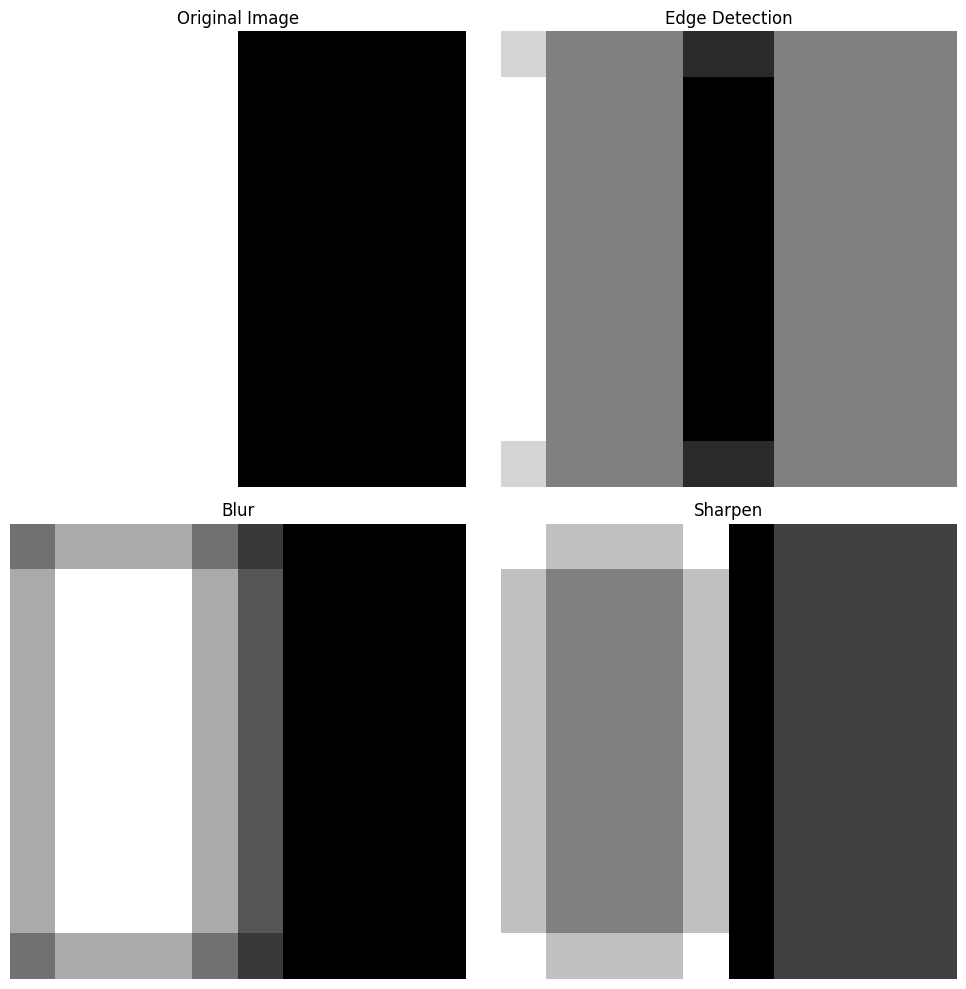

In [14]:
# Common convolution kernels
import matplotlib.pyplot as plt

# Create a simple test image (a gradient with an edge)
test_image = torch.zeros(1, 1, 10, 10)
test_image[0, 0, :, :5] = 1.0  # Left half is white
test_image[0, 0, :, 5:] = 0.0  # Right half is black

# Edge detection kernel (vertical edge detector)
edge_kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0]
]).unsqueeze(0).unsqueeze(0)

# Blur kernel (box blur)
blur_kernel = torch.ones(3, 3) / 9.0
blur_kernel = blur_kernel.unsqueeze(0).unsqueeze(0)

# Sharpen kernel
sharpen_kernel = torch.tensor([
    [0.0, -1.0, 0.0],
    [-1.0, 5.0, -1.0],
    [0.0, -1.0, 0.0]
]).unsqueeze(0).unsqueeze(0)

# Apply kernels
conv_edge = nn.Conv2d(1, 1, 3, padding=1, bias=False)
conv_edge.weight.data = edge_kernel
edge_output = conv_edge(test_image)

conv_blur = nn.Conv2d(1, 1, 3, padding=1, bias=False)
conv_blur.weight.data = blur_kernel
blur_output = conv_blur(test_image)

conv_sharpen = nn.Conv2d(1, 1, 3, padding=1, bias=False)
conv_sharpen.weight.data = sharpen_kernel
sharpen_output = conv_sharpen(test_image)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(test_image.squeeze(), cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(edge_output.squeeze().detach(), cmap='gray')
axes[0, 1].set_title('Edge Detection')
axes[0, 1].axis('off')

axes[1, 0].imshow(blur_output.squeeze().detach(), cmap='gray')
axes[1, 0].set_title('Blur')
axes[1, 0].axis('off')

axes[1, 1].imshow(sharpen_output.squeeze().detach(), cmap='gray')
axes[1, 1].set_title('Sharpen')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


## Part 9: Dilation - Expanding the Receptive Field

**Dilation** (or "atrous convolution") adds gaps between kernel elements, effectively increasing the receptive field without increasing parameters.

- **Dilation=1**: Normal convolution (no gaps)
- **Dilation=2**: One gap between elements (3x3 kernel → 5x5 effective size)
- **Dilation=3**: Two gaps between elements (3x3 kernel → 7x7 effective size)

**Visual example (3x3 kernel, dilation=2):**
```
Normal:       Dilated (d=2):
[X X X]       [X . X . X]
[X X X]       [. . . . .]
[X X X]       [X . X . X]
              [. . . . .]
              [X . X . X]
```


In [15]:
# Convolution with dilation
input_dilated = torch.randn(1, 1, 10, 10)

# Same kernel size, different dilations
conv_d1 = nn.Conv2d(1, 1, kernel_size=3, dilation=1, padding=1, bias=False)
conv_d2 = nn.Conv2d(1, 1, kernel_size=3, dilation=2, padding=2, bias=False)
conv_d3 = nn.Conv2d(1, 1, kernel_size=3, dilation=3, padding=3, bias=False)

out_d1 = conv_d1(input_dilated)
out_d2 = conv_d2(input_dilated)
out_d3 = conv_d3(input_dilated)

print("Input size: 10x10")
print(f"Dilation=1: Output size = {out_d1.squeeze().shape}")
print(f"Dilation=2: Output size = {out_d2.squeeze().shape}")
print(f"Dilation=3: Output size = {out_d3.squeeze().shape}")
print("\nNote: With proper padding, output size stays the same!")
print("But the receptive field (area seen by each output pixel) increases!")

# Calculate effective kernel size
def effective_kernel_size(kernel_size, dilation):
    return kernel_size + (kernel_size - 1) * (dilation - 1)

for d in [1, 2, 3]:
    eff_size = effective_kernel_size(3, d)
    print(f"Dilation={d}: Effective kernel size = {eff_size}x{eff_size}")


Input size: 10x10
Dilation=1: Output size = torch.Size([10, 10])
Dilation=2: Output size = torch.Size([10, 10])
Dilation=3: Output size = torch.Size([10, 10])

Note: With proper padding, output size stays the same!
But the receptive field (area seen by each output pixel) increases!
Dilation=1: Effective kernel size = 3x3
Dilation=2: Effective kernel size = 5x5
Dilation=3: Effective kernel size = 7x7


## Part 10: Transposed Convolution (Deconvolution)

**Transposed convolution** (also called "deconvolution") is used for upsampling - making the output LARGER than the input.

Common uses:
- Image generation (GANs, VAEs)
- Semantic segmentation
- Encoder-decoder architectures

**Key idea:** Instead of sliding and summing, we "unfold" the input and multiply.

**Important:** It's NOT the inverse of convolution! The name is misleading.


In [16]:
# Transposed convolution example
input_small = torch.randn(1, 1, 4, 4)
print("Input size:", input_small.shape)

# Transposed convolution that upsamples 2x
# stride=2 means output will be roughly 2x larger
transposed_conv = nn.ConvTranspose2d(
    in_channels=1, 
    out_channels=1, 
    kernel_size=3, 
    stride=2, 
    padding=1,
    output_padding=1,
    bias=False
)

output_large = transposed_conv(input_small)
print("Output size:", output_large.shape)
print(f"\nUpsampled from {input_small.shape[2]}x{input_small.shape[3]} to {output_large.shape[2]}x{output_large.shape[3]}")

# Compare with regular convolution (downsampling)
regular_conv = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1, bias=False)
output_small = regular_conv(output_large)
print(f"\nRegular conv downsamples back to: {output_small.shape[2]}x{output_small.shape[3]}")


Input size: torch.Size([1, 1, 4, 4])
Output size: torch.Size([1, 1, 8, 8])

Upsampled from 4x4 to 8x8

Regular conv downsamples back to: 4x4


## Part 11: Convolution in Deep Learning Context

In deep learning, convolutions are **learned** - the kernel weights are parameters that get updated during training.

**Key advantages:**
1. **Parameter sharing**: Same kernel used across all positions (translation equivariance)
2. **Sparse connectivity**: Each output only depends on all inputs (due to receptive field)
3. **Local patterns**: Can detect edges, textures, shapes locally

Let's see a simple CNN that learns to detect patterns:


In [17]:
# Simple CNN example
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # First conv layer: 1 channel → 8 channels, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # Second conv layer: 8 channels → 16 channels, 3x3 kernel
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        # Pooling to reduce size
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layer
        self.fc = nn.Linear(16 * 7 * 7, 10)  # Assuming 28x28 input
        
    def forward(self, x):
        # Input: (batch, 1, 28, 28)
        x = F.relu(self.conv1(x))  # (batch, 8, 28, 28)
        x = self.pool(x)            # (batch, 8, 14, 14)
        x = F.relu(self.conv2(x))   # (batch, 16, 14, 14)
        x = self.pool(x)            # (batch, 16, 7, 7)
        x = x.view(x.size(0), -1)   # Flatten: (batch, 16*7*7)
        x = self.fc(x)              # (batch, 10)
        return x

# Create model
model = SimpleCNN()
print("Model architecture:")
print(model)

# Test with dummy input
dummy_input = torch.randn(2, 1, 28, 28)  # Batch of 2, 1 channel, 28x28 images
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# Show conv1 weights shape
print(f"\nConv1 kernel shape: {model.conv1.weight.shape}")
print("  - This represents 8 different 3x3 kernels, each applied to the input")


Model architecture:
SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=784, out_features=10, bias=True)
)

Input shape: torch.Size([2, 1, 28, 28])
Output shape: torch.Size([2, 10])

Total parameters: 9,098

Conv1 kernel shape: torch.Size([8, 1, 3, 3])
  - This represents 8 different 3x3 kernels, each applied to the input


## Part 12: Key Takeaways and Formulas

### Output Size Formula

For regular convolution:
```
H_out = floor((H_in + 2*P - K_h) / S) + 1
W_out = floor((W_in + 2*P - K_w) / S) + 1
```

Where:
- `H_in, W_in`: Input height and width
- `K_h, K_w`: Kernel height and width
- `P`: Padding
- `S`: Stride

### For "Same" Padding (output size = input size)

When `K` is odd:
- `P = (K - 1) / 2`
- `S = 1`

### Effective Kernel Size with Dilation

```
effective_size = K + (K - 1) * (D - 1)
```

Where `D` is the dilation rate.

### Parameter Count

For a conv layer:
```
params = (K_h * K_w * C_in + 1) * C_out
```

The `+1` is for the bias term (if used).


In [18]:
# Quick reference: Parameter counting
def count_conv_params(in_channels, out_channels, kernel_size, bias=True):
    params_per_kernel = kernel_size * kernel_size * in_channels
    if bias:
        params_per_kernel += 1
    total = params_per_kernel * out_channels
    return total

# Example: Conv2d(3, 64, kernel_size=3)
params = count_conv_params(3, 64, 3)
print(f"Conv2d(3, 64, kernel_size=3): {params:,} parameters")
print(f"  - Per kernel: 3×3×3 + 1 = 28 parameters")
print(f"  - Total: 28 × 64 = {params:,} parameters")

# Compare with fully connected layer
# If input was flattened 224x224x3 = 150,528
fc_params = 150528 * 64
print(f"\nEquivalent FC layer: {fc_params:,} parameters")
print(f"Convolution uses {fc_params/params:.1f}x fewer parameters!")


Conv2d(3, 64, kernel_size=3): 1,792 parameters
  - Per kernel: 3×3×3 + 1 = 28 parameters
  - Total: 28 × 64 = 1,792 parameters

Equivalent FC layer: 9,633,792 parameters
Convolution uses 5376.0x fewer parameters!


## Exercises for Practice

Try these exercises to solidify your understanding:

1. **Manual Computation**: Create a 5x5 input and 3x3 kernel, compute the convolution manually, then verify with PyTorch.

2. **Padding Experiment**: Start with a 10x10 input, apply a 3x3 kernel with different padding values (0, 1, 2) and verify the output sizes match the formula.

3. **Stride Experiment**: Use stride=1, 2, 3 on the same input and kernel, compare the output sizes.

4. **Multi-channel**: Create a 3-channel input (simulating RGB), apply a convolution that produces 5 output channels, manually compute one output pixel.

5. **Custom Kernel**: Design your own kernel to detect diagonal edges, horizontal lines, or other patterns.

6. **Parameter Count**: Count parameters in a real CNN architecture (e.g., ResNet18) and verify your calculations.

Good luck! 🚀
